# Data Preprocessing and Feature Engineering
This notebook demonstrates the data mining process, including data loading, cleaning, transformation, feature selection, and saving the preprocessed dataset for model training.

In [1]:
# 1. Import Required Libraries
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 2. Load Raw Dataset
# Example: Load labels and inspect image files
labels_path = 'labels.csv'
images_dir = 'train/'

df = pd.read_csv(labels_path)
print('Labels shape:', df.shape)
df.head()

Labels shape: (10222, 2)


,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


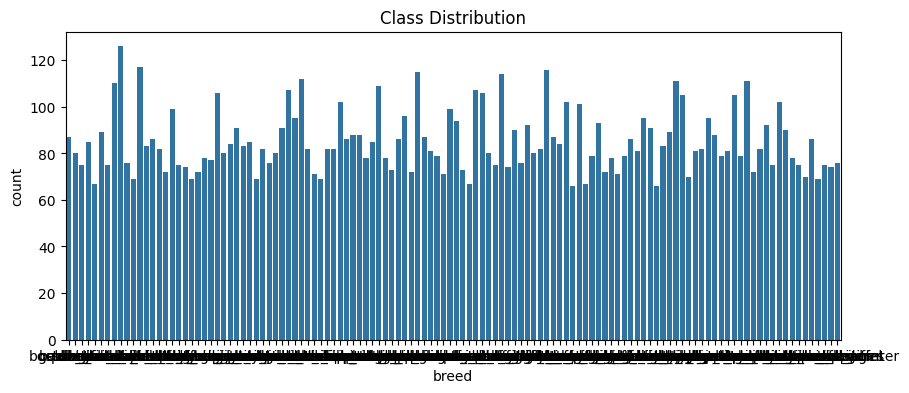

In [8]:
# Visualize class distribution
plt.figure(figsize=(10,4))
sns.countplot(x=df['breed'])
plt.title('Class Distribution')
plt.show()

In [5]:
# 3. Data Cleaning
# Check for missing values and duplicates
print('Missing values per column:')
print(df.isnull().sum())
print('Number of duplicate rows:', df.duplicated().sum())

# Drop duplicates
df = df.drop_duplicates()
# Fill missing values if any (example: fill with mode)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
print('Data shape after cleaning:', df.shape)

Missing values per column:
id       0
breed    0
dtype: int64
Number of duplicate rows: 0
Data shape after cleaning: (10222, 2)


In [ ]:
# 4. Data Transformation
# Encode categorical labels
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

# Example: Normalize numeric features if any
# scaler = StandardScaler()
# df['feature'] = scaler.fit_transform(df[['feature']])

In [ ]:
# 5. Feature Selection (if applicable)
# Example: Select top features using ANOVA F-test
# Here, we assume you have additional features in df
# X = df.drop(['label', 'label_encoded'], axis=1)
# y = df['label_encoded']
# selector = SelectKBest(score_func=f_classif, k=5)
# X_new = selector.fit_transform(X, y)
# selected_features = X.columns[selector.get_support(indices=True)]
# print('Selected features:', selected_features)

# For image classification, feature selection is often not needed as images are processed directly.

In [ ]:
# 6. Save Preprocessed Dataset
# Save the cleaned and transformed labels for later use
df.to_csv('labels_preprocessed.csv', index=False)
print('Preprocessed labels saved to labels_preprocessed.csv')